In [1]:
import geopandas as gpd
import os
import pandas as pd
import osmnx as ox
import folium
from shapely.geometry import box, Point, Polygon
from shapely.validation import make_valid
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
import yaml

In [2]:
# get path to project root directory
project_root = Path.cwd().parents[0]

# build path to yaml config file
config_path = project_root / "configs"/"paths.yaml"

In [3]:
# load yaml file into python dictionary
with open(config_path) as f:
    paths = yaml.safe_load(f)

paths

{'data': {'external': 'data/external',
  'raw': 'data/raw',
  'processed': 'data/processed',
  'results': 'results'},
 'outputs': {'dynamic_maps': 'outputs/maps/dynamic',
  'static_maps': 'output/maps/static',
  'figures': 'output/figures',
  'tables': 'outputs/tables'}}

In [4]:
# build data directory using paths from yaml config
data_dir = project_root/paths['data']['processed']

# build path to external data using paths from yaml config
data_external = project_root/paths['data']['external']

# #  build path to our deduped settlements geojson file
# settlements_path = data_dir / "UNHCR_poc_boundaries-Uganda_attributed_deduped.geojson"

# build path to our regions geojson file
refugee_regions_path = data_external / "refugeehosting_regions.geojson"

In [5]:
# build path to output directory for osm road data
output_dir = project_root/paths['data']['processed']

# build path to output directory for maps
maps_dir = project_root/paths['outputs']['dynamic_maps']

In [6]:
refugee_regions = gpd.read_file(refugee_regions_path)
refugee_regions = gpd.GeoDataFrame(refugee_regions[['ADM2_EN','ADM1_EN', 'ADM0_EN','geometry']], geometry = 'geometry')
refugee_regions["geometry"] = refugee_regions.geometry.apply(make_valid)
refugee_regions = refugee_regions.to_crs(4326)
refugee_regions

,ADM2_EN,ADM1_EN,ADM0_EN,geometry
0,Adjumani,Northern,Uganda,"MULTIPOLYGON (((32.04597 3.58896, 32.04578 3.5..."
1,Amuru,Northern,Uganda,"MULTIPOLYGON (((32.06289 3.57969, 32.06281 3.5..."
2,Arua,Northern,Uganda,"MULTIPOLYGON (((31.17434 3.3474, 31.17463 3.34..."
3,Isingiro,Western,Uganda,"MULTIPOLYGON (((30.77797 -0.60322, 30.77799 -0..."
4,Kamwenge,Western,Uganda,"MULTIPOLYGON (((30.46881 0.57351, 30.46875 0.5..."
5,Kikuube,Western,Uganda,"MULTIPOLYGON (((30.89045 1.54694, 30.91887 1.5..."
6,Kiruhura,Western,Uganda,"MULTIPOLYGON (((31.05885 0.0435, 31.05845 0.04..."
7,Kiryandongo,Western,Uganda,"MULTIPOLYGON (((31.83729 2.36609, 31.83792 2.3..."
8,Kyegegwa,Western,Uganda,"MULTIPOLYGON (((30.91451 0.75863, 30.91575 0.7..."
9,Lamwo,Northern,Uganda,"MULTIPOLYGON (((33.16747 3.78522, 33.17364 3.7..."


In [7]:
region_union_geom = refugee_regions.geometry.unary_union

C:\Users\Zachary\AppData\Local\Temp\ipykernel_35300\1246362135.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_union_geom = refugee_regions.geometry.unary_union


In [9]:
import time

def safe_osm_query(geom, tags, retries=5, wait=5):
    """
    Safe wrapper around ox.features_from_polygon with retry logic.
    """
    for attempt in range(retries):
        try:
            return ox.features_from_polygon(geom, tags)
        except Exception as e:
            print(f"OSM query failed (attempt {attempt+1}/{retries}): {e}")
            if attempt < retries - 1:
                time.sleep(wait)
            else:
                raise

In [22]:
all_roads = safe_osm_query(region_union_geom, tags={"highway": True})

c:\Users\Zachary\anaconda3\envs\uganda-osm\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 42 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
# print the different types of roadway for filtering
all_roads['highway'].value_counts() # note that paths are the most common type

highway
path               55101
unclassified       24158
track              13984
residential        11689
footway             6369
tertiary            1123
service              894
secondary            391
road                 153
crossing             134
primary               98
pedestrian            14
living_street         10
trunk                  9
steps                  8
turning_circle         7
give_way               7
bus_stop               6
platform               6
secondary_link         6
primary_link           6
tertiary_link          4
traffic_mirror         4
trailhead              2
elevator               1
mini_roundabout        1
milestone              1
rest_area              1
street_lamp            1
turning_loop           1
trunk_link             1
Name: count, dtype: int64

In [ ]:
# define list of road and footpath tags 
road_tags = ['primary', 'secondary', 'tertiary',
    'unclassified', 'service', 'give_way', 'crossing', 'secondary_link', 'platform']
footpath_tags = ['path', 'footway', 'track', 'pedestrian', 'steps', 'residential']

# filtering for urban buildup, highway and roadways
roads = all_roads[all_roads['highway'].isin(road_tags)].copy().to_crs(32636)

# filtering for more informal development, footpaths and residential
footpaths = all_roads[all_roads['highway'].isin(footpath_tags)].copy().to_crs(32636)

# filter both of these types of tags
clean_roads = all_roads[all_roads['highway'].isin(road_tags + footpath_tags)].copy().to_crs(32636)

roads = roads[roads.length > 0.0001].to_crs(4326)
footpaths = footpaths[footpaths.length > 0.0001].to_crs(4326)
clean_roads = clean_roads[clean_roads.length > 0.0001].to_crs(4326)

all_roads.to_file(output_dir/"uganda_refugee_regions_osm_all_roads_v1.geojson", driver="GeoJSON")
clean_roads.to_file(output_dir/"uganda_refugee_regions_osm_all_roads_clean_v1.geojson", driver="GeoJSON") 
roads.to_file(output_dir / "uganda_refugee_regions_osm_roads_clean_v1.geojson", driver="GeoJSON") # note we may want to include residential and track in our roads data
footpaths.to_file(output_dir / "uganda_refugee_regions_osm_footpaths_clean_v1.geojson", driver="GeoJSON")

In [ ]:
center_x = refugee_regions.union_all().boundary.centroid.x
center_y = refugee_regions.union_all().boundary.centroid.y
center_point = [center_y, center_x]

m2 = folium.Map(location = center_point,
                 zoom_start = 9, 
                 tiles = None
                 )

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Esri Aerial Imagery',
    show = True
).add_to(m2)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Maps Satellite Imagery',
    name='Google Maps Satellite Imagery',
    show =False
).add_to(m2)

folium.GeoJson(refugee_regions,
               name = "Refugee Hosting Regions",
               style_function = lambda x: {
                   'color': "white",
                   'weight': 3}).add_to(m2)

folium.GeoJson(roads,
               name = "roads",
               style_function=lambda x:{
                   'color': "#ff1500",
                   'weight': 2,
               },
               tooltip = folium.GeoJsonTooltip(fields= [c for c in ['crossing', 'highway']])
               ).add_to(m2)

folium.GeoJson(footpaths,
               name = 'footpaths',
               style_function = lambda x:{
                   'color': "#fff700",
                   'weight': 2
               },
               tooltip = folium.GeoJsonTooltip(fields= [c for c in ['crossing', 'highway']])
               ).add_to(m2)

folium.LayerControl().add_to(m2)
m2.save(maps_dir/"uganda_refugee_regions_osm_overlay.html")
m2

In [10]:
markets_path = data_external/"UG_markets_merged.geojson"
markets = gpd.read_file(markets_path)
markets

,level_0,index,ID,market,country,lat,lon,source,F_id,amenity,...,source_f_1,source_g_2,source_g_3,source_v_1,survey_d_1,vaccinat_1,wb_pb_id_1,layer,path,geometry
0,1.0,1.0,FEWS73,"Bubanza, Kivyuka",Burundi,-3.047900,29.437800,markets_wgs84,None,None,...,None,None,None,None,NaT,None,None,markets_all,C:/Users/sebas/Downloads/markets/markets_all.shp,POINT (29.4378 -3.0479)
1,2.0,2.0,FEWS74,"Bubanza, Musenyi",Burundi,-3.191400,29.409100,markets_wgs84,None,None,...,None,None,None,None,NaT,None,None,markets_all,C:/Users/sebas/Downloads/markets/markets_all.shp,POINT (29.4091 -3.1914)
2,3.0,3.0,FEWS75,"Bubanza, Muzinda",Burundi,-3.230700,29.436800,markets_wgs84,None,None,...,None,None,None,None,NaT,None,None,markets_all,C:/Users/sebas/Downloads/markets/markets_all.shp,POINT (29.4368 -3.2307)
3,4.0,4.0,FEWS78,"Bujumbura Mairie, Chez Siyoni",Burundi,-3.365140,29.357150,markets_wgs84,None,None,...,None,None,None,None,NaT,None,None,markets_all,C:/Users/sebas/Downloads/markets/markets_all.shp,POINT (29.35715 -3.36514)
4,5.0,5.0,FEWS79,"Bujumbura Mairie, Kamenge",Burundi,-3.346010,29.389960,markets_wgs84,None,None,...,None,None,None,None,NaT,None,None,markets_all,C:/Users/sebas/Downloads/markets/markets_all.shp,POINT (29.38996 -3.34601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646,NaN,NaN,node/9727330824,None,None,0.628233,29.940931,osm_points,None,marketplace,...,None,None,None,None,NaT,None,None,UG_market_locs_OSM,C:/Users/sebas/Downloads/markets/UG_market_loc...,POINT (29.94093 0.62823)
2647,NaN,NaN,node/9740884518,None,None,0.628351,29.940062,osm_points,None,marketplace,...,None,None,None,None,NaT,None,None,UG_market_locs_OSM,C:/Users/sebas/Downloads/markets/UG_market_loc...,POINT (29.94006 0.62835)
2648,NaN,NaN,node/9822428540,None,None,-1.263344,29.981547,osm_points,None,marketplace,...,None,None,None,None,NaT,None,None,UG_market_locs_OSM,C:/Users/sebas/Downloads/markets/UG_market_loc...,POINT (29.98155 -1.26334)
2649,NaN,NaN,node/9822495942,None,None,-1.272585,29.991959,osm_points,None,marketplace,...,None,None,None,None,NaT,None,None,UG_market_locs_OSM,C:/Users/sebas/Downloads/markets/UG_market_loc...,POINT (29.99196 -1.27258)


In [11]:
# Clean any problematic columns
for col in ["level_0", "index", "index_left", "index_right"]:
    if col in markets.columns:
        markets = markets.drop(columns=[col])
    if col in refugee_regions.columns:
        refugee_regions = refugee_regions.drop(columns=[col])

# Ensure matching CRS
markets = markets.to_crs(refugee_regions.crs)

# Spatial join: keep only markets inside refugee hosting regions
markets_in_regions = gpd.sjoin(
    markets,
    refugee_regions[["geometry"]],
    how="inner",
    predicate="within"
).drop(columns=["index_right"])


markets_in_regions.reset_index(names = 'marketID', inplace = True)

columns_to_keep = ['marketID','ID','market', 'source', 'amenity', 'layer', 'geometry']
markets_in_regions = markets_in_regions[columns_to_keep]
markets_in_regions


,marketID,ID,market,source,amenity,layer,geometry
0,982,FEWS1250,Arua,markets_wgs84,None,markets_all,POINT (30.91 3.02155)
1,1926,node/1657296223,None,osm_points,marketplace,UG_market_locs_OSM,POINT (30.94034 3.01241)
2,1927,node/1657301235,None,osm_points,marketplace,UG_market_locs_OSM,POINT (30.96933 3.03148)
3,2024,node/4502308285,None,osm_points,marketplace,UG_market_locs_OSM,POINT (31.35436 3.45735)
4,2025,node/4502308286,None,osm_points,marketplace,UG_market_locs_OSM,POINT (31.4044 3.47514)
...,...,...,...,...,...,...,...
340,2416,node/5998326993,None,HOT-Uganda,marketplace,UG_market_locs_OSM,POINT (30.79235 1.16)
341,2449,node/6282700270,None,HOT_Uganda,marketplace,UG_market_locs_OSM,POINT (30.95593 -0.77717)
342,2450,node/6282700650,None,HOT_Uganda,marketplace,UG_market_locs_OSM,POINT (30.94921 -0.7839)
343,2451,node/6282700657,None,HOT_Uganda,marketplace,UG_market_locs_OSM,POINT (30.92 -0.73099)


In [37]:
markets_in_regions.to_file(output_dir/'uganda_markets_clean_v1.geojson', driver = 'geojson')

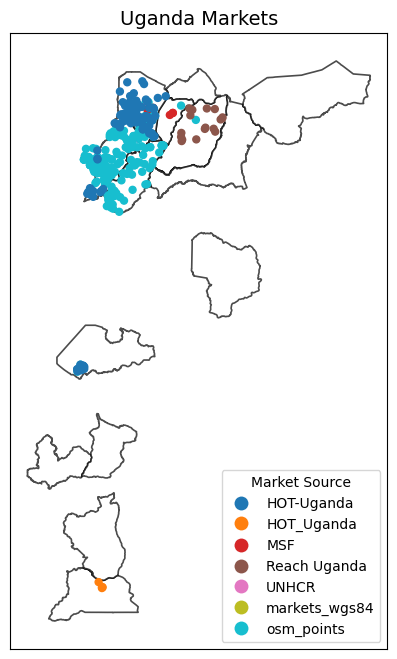

In [12]:
# Plot
fig, ax = plt.subplots(figsize=(10, 8))

refugee_regions.plot(
    ax=ax, color="white", edgecolor="black",
    alpha=0.7, linewidth=1.2, label="Refugee Regions"
)

markets_in_regions.plot(
    ax=ax,
    column="source",
    categorical=True,
    legend=True,
    legend_kwds={"title": "Market Source"},
    markersize=25,
)

ax.set_title("Uganda Markets", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [8]:
from sqlalchemy import create_engine
import psycopg2
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

DB = os.getenv("PGDATABASE")
USER = os.getenv("PGUSER")
PWD = os.getenv("PGPASSWORD")
HOST = os.getenv("PGHOST")
PORT = os.getenv("PGPORT")


conn = psycopg2.connect(
    dbname=DB,
    user=USER,
    password=PWD,
    host=HOST,
    port=PORT
)

engine = create_engine(f"postgresql://{USER}:{PWD}@{HOST}:{PORT}/{DB}")

In [14]:
target_crs = "EPSG:32636"

# build paths to our hexbins
areas = [250, 62, 15]

hexbin_paths = {
    f"hex_{area}k": data_dir/f"uganda_hexbins_{area}k_lcluc_v1.geojson" for area in areas
}
hex_250k_path = hexbin_paths['hex_250k']
hex_62k_path = hexbin_paths['hex_62k']
hex_15k_path = hexbin_paths['hex_15k']

# build paths to other datasets
roads_path = data_dir/"uganda_refugee_regions_osm_roads_clean_v1.geojson"
markets_path = data_dir/"uganda_markets_clean_v1.geojson"

In [40]:
hex_250k = gpd.read_file(hex_250k_path).to_crs(32636)
hex_62k = gpd.read_file(hex_62k_path).to_crs(32636)
hex_15k = gpd.read_file(hex_15k_path).to_crs(32636)
roads = gpd.read_file(roads_path).to_crs(32636)
markets = gpd.read_file(markets_path).to_crs(32636)

In [44]:
import geoalchemy2

hex_250k.to_postgis("hex_250k", engine, if_exists="replace", index=False)
hex_62k.to_postgis("hex_62k", engine, if_exists="replace", index=False)
hex_15k.to_postgis("hex_15k", engine, if_exists="replace", index=False)
roads.to_postgis("roads", engine, if_exists="replace", index=False)
markets.to_postgis("markets", engine, if_exists="replace", index=False)

In [9]:
def run_sql(sql):
    cur = conn.cursor()
    try:
        cur.execute(sql)
        conn.commit()
    except Exception as e:
        conn.rollback()
        print("SQL error:", e)
    cur.close()

In [50]:
# add centroid column to hexbin dataset
run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS centroid geometry(Point, 32636);
UPDATE hex_250k 
    SET centroid = ST_Centroid(geometry);
""")

In [ ]:
# add centroid column to hexbin dataset
run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS centroid geometry(Point, 32636);
UPDATE hex_62k 
    SET centroid = ST_Centroid(geometry);
""")

In [ ]:
# add centroid column to hexbin dataset
run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS centroid geometry(Point, 32636);
UPDATE hex_15k 
    SET centroid = ST_Centroid(geometry);
""")

In [55]:
run_sql("""
CREATE INDEX IF NOT EXISTS roads_gist 
    ON roads USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS markets_gist 
    ON markets USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS hex_250k_centroid_gist 
    ON hex_250k USING GIST (centroid);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS hex_62k_centroid_gist 
    ON hex_62k USING GIST (centroid);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS hex_15k_centroid_gist 
    ON hex_15k USING GIST (centroid);
""")

In [58]:
run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_road double precision;

UPDATE hex_250k h
SET dist_to_road =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM roads r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [59]:
run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_road double precision;

UPDATE hex_62k h
SET dist_to_road =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM roads r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [61]:
run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_road double precision;

UPDATE hex_15k h
SET dist_to_road =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM roads r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [62]:
run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_market double precision;

UPDATE hex_250k h
SET dist_to_market =
(
    SELECT ST_Distance(h.centroid, m.geometry)
    FROM markets m
    ORDER BY h.centroid <-> m.geometry
    LIMIT 1
);
""")

In [63]:
run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_market double precision;

UPDATE hex_62k h
SET dist_to_market =
(
    SELECT ST_Distance(h.centroid, m.geometry)
    FROM markets m
    ORDER BY h.centroid <-> m.geometry
    LIMIT 1
);
""")

In [64]:
run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_market double precision;

UPDATE hex_15k h
SET dist_to_market =
(
    SELECT ST_Distance(h.centroid, m.geometry)
    FROM markets m
    ORDER BY h.centroid <-> m.geometry
    LIMIT 1
);
""")

In [129]:
pop_centers = gpd.read_file(data_external/'hotosm_populated_places.geojson').to_crs(32636)
rivers = gpd.read_file(data_external/'hotosm_waterways.geojson').to_crs(32636)

In [113]:
# filter out isolated dwellings and other unnecessary tags
tags_1 = ['city', 'town', 'village', 'hamlet']
tags_2 = ['city', 'town', 'village']
tags_3 = ['city', 'town']
tags_4 = ['city']


pop_centers_1 = pop_centers[pop_centers['place'].isin(tags_1)]
pop_centers_2 = pop_centers[pop_centers['place'].isin(tags_2)]
pop_centers_3 = pop_centers[pop_centers['place'].isin(tags_3)]
pop_centers_4 = pop_centers[pop_centers['place'].isin(tags_4)]

In [130]:
rivers_plus = rivers[rivers['waterway'].isin(['river', 'stream', 'canal', 'wadi', 'brook', 'waterfall', 'rapids', 'oxbow'])]
rivers_and_streams = rivers[rivers['waterway'].isin(['river', 'stream'])]
rivers = rivers[rivers['waterway'].isin(['river'])]

In [131]:
rivers.to_postgis("rivers", engine, if_exists="replace", index=False)
rivers_and_streams.to_postgis("rivers_and_streams", engine, if_exists="replace", index=False)
rivers_plus.to_postgis("rivers_plus", engine, if_exists="replace", index=False)
pop_centers_1.to_postgis("pop_centers_1", engine, if_exists="replace", index=False)
pop_centers_2.to_postgis("pop_centers_2", engine, if_exists="replace", index=False)
pop_centers_3.to_postgis("pop_centers_3", engine, if_exists="replace", index=False)
pop_centers_4.to_postgis("pop_centers_4", engine, if_exists="replace", index=False)

In [141]:
# rivers.to_file(output_dir/'uganda_rivers.geojson', driver = 'geojson')
# rivers_and_streams.to_file(output_dir/'uganda_rivers_and_streams.geojson', driver = 'geojson')
# rivers_plus.to_file(output_dir/'uganda_rivers_plus.geojson', driver = 'geojson')
# pop_centers_1.to_file(output_dir/'uganda_population_centers_v1.geojson', driver = 'geojson')
# pop_centers_2.to_file(output_dir/'uganda_population_centers_v2.geojson', driver = 'geojson')
# pop_centers_3.to_file(output_dir/'uganda_population_centers_v3.geojson', driver = 'geojson')
# pop_centers_4.to_file(output_dir/'uganda_population_centers_v4.geojson', driver = 'geojson')

In [10]:
run_sql("""
CREATE INDEX IF NOT EXISTS rivers_gist 
    ON rivers USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS rivers_and_streams_gist 
    ON rivers_and_streams USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS rivers_plus_gist 
    ON rivers_plus USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS pop_centers_1_gist 
    ON pop_centers_1 USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS pop_centers_2_gist 
    ON pop_centers_2 USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS pop_centers_3_gist 
    ON pop_centers_3 USING GIST (geometry);
""")

run_sql("""
CREATE INDEX IF NOT EXISTS pop_centers_4_gist 
    ON pop_centers_4 USING GIST (geometry);
""")

In [136]:
run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers double precision;

UPDATE hex_250k h
SET dist_to_rivers =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_and_streams double precision;

UPDATE hex_250k h
SET dist_to_rivers_and_streams =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_and_streams r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_plus double precision;

UPDATE hex_250k h
SET dist_to_rivers_plus =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_plus r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [137]:
run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers double precision;

UPDATE hex_62k h
SET dist_to_rivers =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_and_streams double precision;

UPDATE hex_62k h
SET dist_to_rivers_and_streams =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_and_streams r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_plus double precision;

UPDATE hex_62k h
SET dist_to_rivers_plus =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_plus r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [138]:
run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers double precision;

UPDATE hex_15k h
SET dist_to_rivers =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_and_streams double precision;

UPDATE hex_15k h
SET dist_to_rivers_and_streams =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_and_streams r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_rivers_plus double precision;

UPDATE hex_15k h
SET dist_to_rivers_plus =
(
    SELECT ST_Distance(h.centroid, r.geometry)
    FROM rivers_plus r
    ORDER BY h.centroid <-> r.geometry
    LIMIT 1
);
""")

In [139]:
run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_1 double precision;

UPDATE hex_250k h
SET dist_to_pop_center_1 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_1 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_2 double precision;

UPDATE hex_250k h
SET dist_to_pop_center_2 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_2 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_3 double precision;

UPDATE hex_250k h
SET dist_to_pop_center_3 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_3 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_250k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_4 double precision;

UPDATE hex_250k h
SET dist_to_pop_center_4 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_4 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

In [140]:
run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_1 double precision;

UPDATE hex_62k h
SET dist_to_pop_center_1 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_1 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_2 double precision;

UPDATE hex_62k h
SET dist_to_pop_center_2 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_2 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_3 double precision;

UPDATE hex_62k h
SET dist_to_pop_center_3 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_3 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_62k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_4 double precision;

UPDATE hex_62k h
SET dist_to_pop_center_4 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_4 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

In [10]:
run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_1 double precision;

UPDATE hex_15k h
SET dist_to_pop_center_1 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_1 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_2 double precision;

UPDATE hex_15k h
SET dist_to_pop_center_2 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_2 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_3 double precision;

UPDATE hex_15k h
SET dist_to_pop_center_3 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_3 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

run_sql("""
ALTER TABLE hex_15k 
    ADD COLUMN IF NOT EXISTS dist_to_pop_center_4 double precision;

UPDATE hex_15k h
SET dist_to_pop_center_4 =
(
    SELECT ST_Distance(h.centroid, p.geometry)
    FROM pop_centers_4 p
    ORDER BY h.centroid <-> p.geometry
    LIMIT 1
);
""")

In [8]:
hex_250k_processed = gpd.read_postgis(
    "SELECT * FROM hex_250k", 
    con=engine, 
    geom_col="geometry"
)

hex_62k_processed = gpd.read_postgis(
    "SELECT * FROM hex_62k", 
    con=engine, 
    geom_col="geometry"
)

# hex_15k_processed = gpd.read_postgis(
#     "SELECT * FROM hex_15k", 
#     con=engine, 
#     geom_col="geometry"
# )


In [9]:
hex_250k_processed.to_file(output_dir/'uganda_hexbins_250k_lcluc_processed_v1.geojson', driver = 'GeoJSON')
hex_62k_processed.to_file(output_dir/'uganda_hexbins_62k_lcluc_processed_v1.geojson', driver = 'GeoJSON')
# hex_15k_processed.to_file(output_dir/'uganda_hexbins_15k_lcluc_processed_v1.geojson', driver = 'GeoJSON')

In [ ]:
import geopandas as gpd
import folium

# ----------------------------------------------------
# Load datasets
# ----------------------------------------------------
regions = gpd.read_file(data_external / "refugeehosting_regions.geojson")
pop_centers_1 = gpd.read_file(data_dir/ "uganda_population_centers_v1.geojson")
pop_centers_2 = gpd.read_file(data_dir/ "uganda_population_centers_v2.geojson")
rivers = gpd.read_file(data_dir/ "uganda_rivers.geojson")
rivers_and_streams = gpd.read_file(data_dir/ "uganda_rivers_and_streams.geojson")

In [144]:
pop_centers_3 = gpd.read_file(data_dir/ "uganda_population_centers_v3.geojson")

In [151]:
regions = regions.to_crs(32636)
pop_centers_1 = pop_centers_1.to_crs(32636)
pop_centers_2 = pop_centers_2.to_crs(32636)
pop_centers_3 = pop_centers_3.to_crs(32636)
rivers = rivers.to_crs(32636)
rivers_and_streams = rivers_and_streams.to_crs(32636)

In [152]:
# ----------------------------------------------------
# Extract Obongi region
# ----------------------------------------------------
obongi = regions.loc[
    regions["ADM2_EN"].str.contains("Obongi", case=False)
].geometry.iloc[0]

# Ensure Obongi is in the same CRS as your datasets before clipping
# Assumes pop_centers_X, rivers, rivers_and_streams are in EPSG:32636
obongi_32636 = gpd.GeoSeries([obongi], crs=regions.crs).to_crs(32636).iloc[0]

# ----------------------------------------------------
# Clip buildings + population centers to Obongi
# ----------------------------------------------------
pop1_obongi = gpd.clip(pop_centers_1, obongi_32636).to_crs(4326)
pop2_obongi = gpd.clip(pop_centers_2, obongi_32636).to_crs(4326)
pop3_obongi = gpd.clip(pop_centers_3, obongi_32636).to_crs(4326)

rivers_obongi = gpd.clip(rivers, obongi_32636).to_crs(4326)
rivers_and_streams_obongi = gpd.clip(rivers_and_streams, obongi_32636).to_crs(4326)

# Convert Obongi for folium
obongi_4326 = gpd.GeoSeries([obongi], crs=regions.crs).to_crs(4326).iloc[0]

# ----------------------------------------------------
# Create folium map
# ----------------------------------------------------
center = [obongi_4326.centroid.y, obongi_4326.centroid.x]
m = folium.Map(location=center, zoom_start=11, tiles=None)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Esri Aerial Imagery',
    show=True
).add_to(m)

# ----------------------------------------------------
# Add Obongi region boundary
# ----------------------------------------------------
folium.GeoJson(
    obongi_4326,
    name="Obongi Region",
    style_function=lambda x: {
        "fillColor": "none",
        "color": "blue",
        "weight": 3,
    },
).add_to(m)

# ----------------------------------------------------
# Add rivers
# ----------------------------------------------------
folium.GeoJson(
    rivers_obongi,
    name="Rivers",
    style_function=lambda x: {"color": "#666666", "weight": 1},
).add_to(m)

folium.GeoJson(
    rivers_and_streams_obongi,
    name="Rivers and Streams",
    style_function=lambda x: {"color": "#444444", "weight": 1},
).add_to(m)

# ----------------------------------------------------
# Add population centers
# ----------------------------------------------------
folium.GeoJson(
    pop1_obongi,
    name="Pop Centers 1",
    style_function=lambda x: {"color": "#868244", "weight": 6},
).add_to(m)

folium.GeoJson(
    pop2_obongi,
    name="Pop Centers 2",
    style_function=lambda x: {"color": "#0F6584", "weight": 6},
).add_to(m)

folium.GeoJson(
    pop3_obongi,
    name="Pop Centers 3",
    style_function=lambda x: {"color": "#9716AA", "weight": 6},
).add_to(m)

# ----------------------------------------------------
# Layer control
# ----------------------------------------------------
folium.LayerControl().add_to(m)

# Show in notebook
m

# Save to file
m.save(maps_dir / "uganda_pop_centers_rivers_overlay.html")
